In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import linregress

from pathlib import Path

In [2]:
nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

funds = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

benchmark = pd.read_csv(
    "../data/processed/clean_benchmark_indices.csv"
)

performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

In [3]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [4]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (

    nav.groupby("amfi_code")["nav"]

       .pct_change()

)

In [5]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

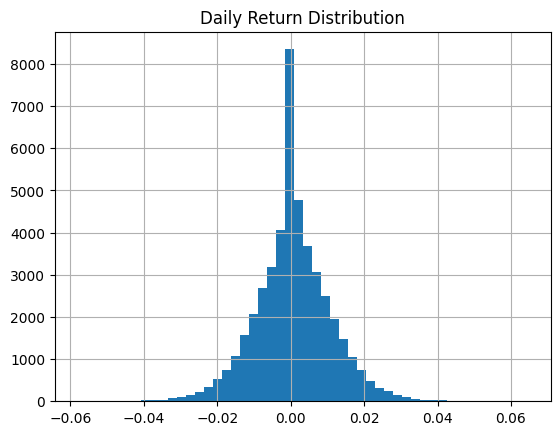

In [6]:
nav["daily_return"].hist(
    bins=50
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [7]:
def calculate_cagr(df, years):

    latest_date = df["date"].max()

    start_date = (
        latest_date -
        pd.DateOffset(years=years)
    )

    subset = df[
        df["date"] >= start_date
    ]

    if len(subset) < 2:
        return np.nan

    start_nav = subset.iloc[0]["nav"]

    end_nav = subset.iloc[-1]["nav"]

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    return cagr

In [8]:
cagr_table = []

for code in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == code
    ]

    cagr_table.append({

        "amfi_code": code,

        "cagr_1yr":
            calculate_cagr(
                fund_data,
                1
            ),

        "cagr_3yr":
            calculate_cagr(
                fund_data,
                3
            ),

        "cagr_5yr":
            calculate_cagr(
                fund_data,
                5
            )

    })

cagr_df = pd.DataFrame(
    cagr_table
)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [9]:
RF = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = (

        nav[
            nav["amfi_code"] == code
        ]["daily_return"]

        .dropna()

    )

    annual_return = (
        returns.mean() * 252
    )

    annual_std = (
        returns.std() *
        np.sqrt(252)
    )

    sharpe = (

        (annual_return - RF)

        / annual_std

    )

    sharpe_results.append({

        "amfi_code": code,

        "sharpe_ratio": sharpe

    })

sharpe_df = pd.DataFrame(
    sharpe_results
)

In [10]:
sortino_results = []

for code in nav["amfi_code"].unique():

    returns = (

        nav[
            nav["amfi_code"] == code
        ]["daily_return"]

        .dropna()

    )

    downside = (
        returns[
            returns < 0
        ]
    )

    downside_std = (

        downside.std()

        * np.sqrt(252)

    )

    annual_return = (
        returns.mean() * 252
    )

    sortino = (

        (annual_return - RF)

        / downside_std

    )

    sortino_results.append({

        "amfi_code": code,

        "sortino_ratio": sortino

    })

sortino_df = pd.DataFrame(
    sortino_results
)

In [11]:
nifty100 = benchmark[
    benchmark["index_name"]
    == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [12]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][
        ["date", "daily_return"]
    ]

    merged = pd.merge(

        fund,

        nifty100[
            ["date",
             "benchmark_return"]
        ],

        on="date"

    ).dropna()

    if len(merged) < 20:
        continue

    beta, alpha, _, _, _ = (

        linregress(

            merged["benchmark_return"],

            merged["daily_return"]

        )

    )

    alpha_beta.append({

        "amfi_code": code,

        "alpha": alpha * 252,

        "beta": beta

    })

alpha_beta_df = pd.DataFrame(
    alpha_beta
)

In [13]:
alpha_beta_df.to_csv(

    "../data/processed/alpha_beta.csv",

    index=False

)

In [14]:
drawdowns = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund["running_max"] = (
        fund["nav"].cummax()
    )

    fund["drawdown"] = (

        fund["nav"]

        / fund["running_max"]

        - 1

    )

    drawdowns.append({

        "amfi_code": code,

        "max_drawdown":
            fund["drawdown"].min()

    })

drawdown_df = pd.DataFrame(
    drawdowns
)

In [15]:
scorecard = (

    performance[
        ["amfi_code",
         "return_3yr_pct",
         "expense_ratio_pct"]
    ]

    .merge(
        sharpe_df,
        on="amfi_code"
    )

    .merge(
        alpha_beta_df,
        on="amfi_code"
    )

    .merge(
        drawdown_df,
        on="amfi_code"
    )

)

In [16]:
scorecard["score"] = (

    scorecard["return_3yr_pct"]
        .rank(pct=True) * 30

    +

    scorecard["sharpe_ratio"]
        .rank(pct=True) * 25

    +

    scorecard["alpha"]
        .rank(pct=True) * 20

    +

    scorecard["expense_ratio_pct"]
        .rank(
            pct=True,
            ascending=False
        ) * 15

    +

    scorecard["max_drawdown"]
        .rank(
            pct=True,
            ascending=False
        ) * 10

)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

In [17]:
scorecard.to_csv(

    "../data/processed/fund_scorecard.csv",

    index=False

)

In [18]:
top5 = scorecard.head(5)[
    "amfi_code"
]

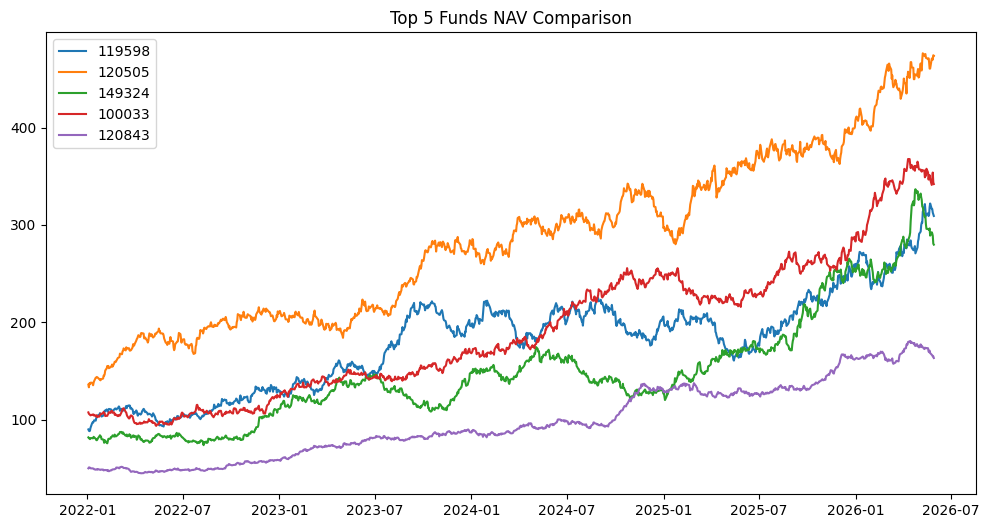

In [19]:
plt.figure(
    figsize=(12,6)
)

for code in top5:

    fund = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(

        fund["date"],

        fund["nav"],

        label=str(code)

    )

plt.legend()

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.savefig(

    "../reports/benchmark_comparison.png",

    bbox_inches="tight"

)

plt.show()